### API KEY 및 환경설정

In [1]:
# 운영체제 관련 기능을 사용하기 위한 os 모듈을 불러옵니다.
import os

# LangChain에서 채팅 모델을 초기화하는 함수를 불러옵니다.
from langchain.chat_models import init_chat_model

# 환경변수를 파일에서 불러오기 위한 load_dotenv 함수를 불러옵니다.
from dotenv import load_dotenv

# 지정한 경로의 .env 파일을 읽어 환경변수를 현재 실행 환경에 로드합니다.
load_dotenv("/home/user/MultiAgents/.env")

# 프록시 서버를 통해 gpt-4o-mini 채팅 모델을 초기화합니다.
model = init_chat_model(
    "gpt-4o-mini",  # 사용할 모델 이름을 지정합니다.
    api_key=os.environ["PROXY_TOKEN"],  # 환경변수에서 프록시 인증 토큰을 가져옵니다.
    base_url=os.environ["PROXY_URL"],  # 환경변수에서 프록시 서버 주소를 가져옵니다.
    temperature=0,  # 출력의 랜덤성을 0으로 설정해 일관된 응답을 유도합니다.
)

# Multi-agent
* 복잡한 workflow 개념이 아닌 하위 agent 개념의 agent
    * 더 복잡한 workflow는 langgraph로 구현가능
* Tool 기반 하위 agent를 구현하는 방식으로 Multi-agent 구현


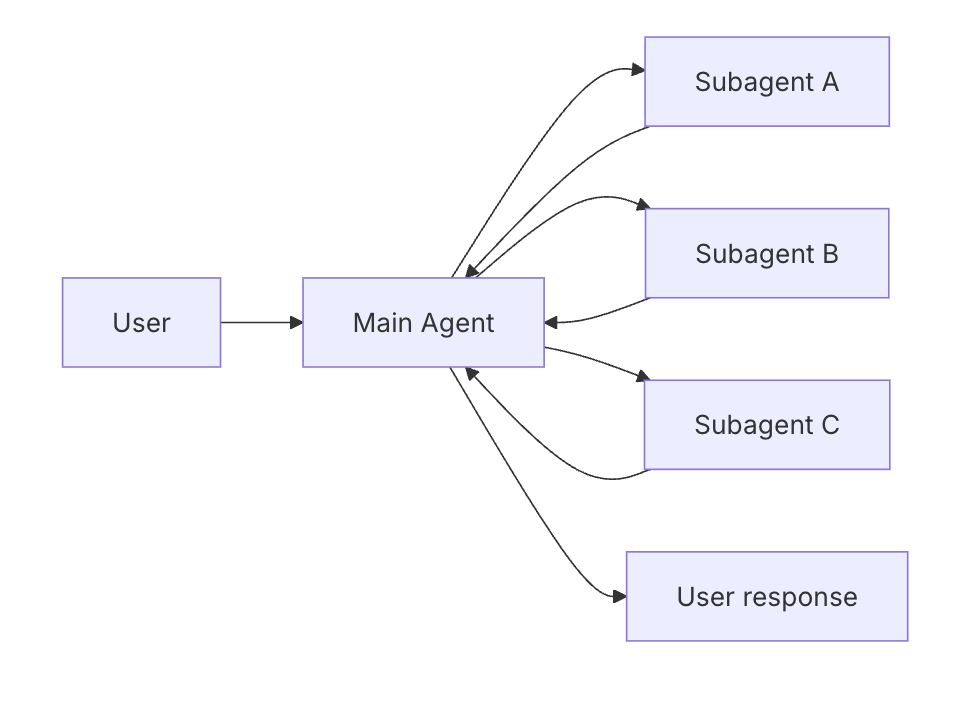

* 간단히 Agent가 Tool로 Agent를 부르며 Context window를 독립해 작업을 실행합니다.

### Subagent 구현하기
* Tool 형태로 subagent를 구현합니다.

In [2]:
# LangChain의 tool 데코레이터를 불러옵니다.
from langchain.tools import tool

# LangChain 에이전트를 생성하는 함수를 불러옵니다.
from langchain.agents import create_agent

# ---------------------------
# Sub Agent
# ---------------------------

# 별도 도구 없이 동작하는 서브 에이전트를 생성합니다.
subagent = create_agent(
    model=model,  # 미리 정의된 모델을 서브 에이전트에 연결합니다.
    tools=[]  # 서브 에이전트는 별도의 도구 없이 동작합니다.
)

# ---------------------------
# Tool 정의 (로그 추가)
# ---------------------------

# research라는 이름의 도구를 정의합니다.
@tool(
    "research",  # 도구의 이름을 research로 지정합니다.
    description="연구 주제를 기반으로 답변을 검색 혹은 생성하세요"  # 도구의 역할을 설명합니다.
)
# 서브 에이전트를 호출하는 research 도구 함수를 정의합니다.
def call_research_agent(query: str):
    # 도구가 호출되었음을 콘솔에 출력합니다.
    print("🛠️ [TOOL CALLED] research tool invoked")

    # 입력받은 질의를 콘솔에 출력합니다.
    print(f"📝 Query: {query}")

    # 서브 에이전트에 사용자 메시지 형태로 질의를 전달하여 실행합니다.
    result = subagent.invoke({
        "messages": [
            {"role": "user", "content": query}  # query를 사용자 메시지로 전달합니다.
        ]
    })

    # 서브 에이전트의 마지막 응답 메시지 내용을 추출합니다.
    output = result["messages"][-1].content

    # 도구 실행 결과가 나왔음을 콘솔에 출력합니다.
    print("✅ [TOOL RESULT]")

    # 추출한 결과 내용을 콘솔에 출력합니다.
    print(output)

    # 메인 에이전트가 사용할 수 있도록 결과를 반환합니다.
    return output


# ---------------------------
# Main Agent
# ---------------------------

# research 도구를 사용할 수 있는 메인 에이전트를 생성합니다.
main_agent = create_agent(
    model=model,  # 미리 정의된 모델을 메인 에이전트에 연결합니다.
    tools=[call_research_agent],  # 메인 에이전트가 사용할 도구로 research 도구를 등록합니다.
    system_prompt=(
        "당신은 메인 에이전트입니다. "  # 에이전트의 역할을 정의합니다.
        "사용자가 리서치나 사실 확인이 필요한 조사성 질문을 할 경우, "  # 어떤 상황에서 도구를 써야 하는지 지정합니다.
        "반드시 리서치 도구를 사용해야 합니다."  # 조사성 질문에는 반드시 research 도구를 사용하도록 강제합니다.
    )
)


# ---------------------------
# 실행 예제
# ---------------------------

# 메인 에이전트에 사용자 질문을 전달하여 실행합니다.
response = main_agent.invoke({
    "messages": [
        {
            "role": "user",  # 사용자 역할의 메시지임을 나타냅니다.
            "content": "전세계에서 강수량이 가장 높은 지역이 어디인지 조사해줘."  # 조사성 질문을 전달합니다.
        }
    ]
})

# 최종 응답 출력 전 구분용 문구를 출력합니다.
print("\n🤖 [MAIN AGENT FINAL RESPONSE]")

# 메인 에이전트의 마지막 응답 메시지 내용을 출력합니다.
print(response["messages"][-1].content)

🛠️ [TOOL CALLED] research tool invoked
📝 Query: 전세계에서 강수량이 가장 높은 지역
✅ [TOOL RESULT]
전세계에서 강수량이 가장 높은 지역은 인도의 "무나르"와 "마우시날롱"입니다. 특히 마우시날롱은 인도 북동부의 메갈라야 주에 위치해 있으며, 연평균 강수량이 약 467.4인치(약 11,871mm)에 달합니다. 이 지역은 몬순 기후의 영향을 받아 매우 많은 비가 내리는 것으로 유명합니다. 

또한, 파푸아뉴기니의 "크리스트마스 섬"과 콜롬비아의 "레티시아" 지역도 강수량이 많은 곳으로 알려져 있습니다. 이러한 지역들은 지리적 특성과 기후 조건으로 인해 높은 강수량을 기록하고 있습니다.

🤖 [MAIN AGENT FINAL RESPONSE]
전세계에서 강수량이 가장 높은 지역은 인도의 "마우시날롱"입니다. 이 지역은 인도 북동부의 메갈라야 주에 위치해 있으며, 연평균 강수량이 약 467.4인치(약 11,871mm)에 달합니다. 마우시날롱은 몬순 기후의 영향을 받아 매우 많은 비가 내리는 것으로 유명합니다.

또한, 인도의 "무나르", 파푸아뉴기니의 "크리스트마스 섬", 콜롬비아의 "레티시아" 지역도 강수량이 많은 곳으로 알려져 있습니다. 이러한 지역들은 지리적 특성과 기후 조건으로 인해 높은 강수량을 기록하고 있습니다.


### Skills

### 직장인 휴가 요청 → 등록(LangChain 에이전트) 예제 (더미)

### 개요
이 문서는 **LangChain 에이전트**를 사용하여  
직장인이 **휴가 요청 → HR 시스템에 등록(더미)** 까지 처리하는 흐름을 설명하는 예제입니다.  
실제 DB나 사내 시스템과 연동하지 않고, **동작 구조를 이해하기 위한 더미 코드**를 전제로 합니다.

---

### 핵심 포인트

- **Skills 구조**
  - `load_skill()` 함수가 **파일이나 DB를 참조하지 않고**
  - **Markdown 텍스트를 직접 return** 하도록 구성됩니다.

- **에이전트 동작 흐름**
  1. 사용자의 입력을 분석합니다.
  2. 휴가 요청과 관련된 경우  
     `load_skill("request_vacation")`을 호출하여  
     휴가 정책 및 필요한 입력 항목을 로드합니다.
  3. 필요한 정보(휴가 종류, 기간, 사유 등)를 정리합니다.
  4. `register_vacation_request()` 더미 툴을 호출합니다.
  5. 실제로는 저장하지 않지만  
     **“등록된 것처럼” 결과를 반환**합니다.

- **휴가 등록 처리**
  - HR 시스템은 실제 연동되지 않습니다.
  - 요청 번호, 상태 등은 **더미 데이터**로 생성됩니다.


In [3]:
# 타입 힌트용 Optional, Dict, Any를 불러옵니다.
from typing import Optional, Dict, Any

# 날짜 문자열을 datetime 객체로 변환하기 위해 datetime을 불러옵니다.
from datetime import datetime

# LangChain의 tool 데코레이터를 불러옵니다.
from langchain.tools import tool

# LangChain 에이전트를 생성하는 함수를 불러옵니다.
from langchain.agents import create_agent


# -----------------------------
# 1) Skill Loader (Markdown 직접 반환)
# -----------------------------

# 스킬 이름을 받아 해당 스킬의 마크다운 프롬프트를 반환하는 도구를 정의합니다.
@tool
def load_skill(skill_name: str) -> str:
    # 함수의 역할과 사용 가능한 스킬 목록을 설명하는 독스트링입니다.
    """Load a specialized skill prompt as markdown text.

    Available skills:
    - request_vacation: 휴가 요청/등록 도우미
    - review_legal_doc: (예시용) 법률 문서 리뷰어
    """
    # 요청된 스킬이 휴가 요청 스킬인 경우 해당 마크다운을 반환합니다.
    if skill_name == "request_vacation":
        return """# ✅ Skill: request_vacation (휴가 요청/등록)

                ## 목적
                직장인의 휴가 요청을 표준 포맷으로 정리하고, HR 시스템(더미)에 등록합니다.

                ## 입력으로 확보해야 할 정보(필수)
                - 휴가 종류: 연차/반차/병가/기타
                - 기간: 시작일 ~ 종료일 (YYYY-MM-DD)
                - 사유(짧게)
                - 인수인계 내용(짧게)
                - 대체 담당자(있으면)

                ## 규칙(더미 정책)
                - 시작일은 종료일보다 늦을 수 없습니다.
                - 과거 날짜만으로 신청하면 경고(더미).
                - 사유는 5자 이상 권장.

                ## 출력 포맷(최종 답변)
                - 요약(휴가 종류, 기간, 일수 추정)
                - 등록 결과(요청번호, 상태)
                - 유의사항(필요 시)
                    """
    # 요청된 스킬이 법률 문서 리뷰 스킬인 경우 간단한 마크다운을 반환합니다.
    if skill_name == "review_legal_doc":
        return """# Skill: review_legal_doc (더미) 법률 문서 리뷰어"""

    # 정의되지 않은 스킬 이름이 들어오면 안내 문구를 반환합니다.
    return f"# Unknown skill: {skill_name}\n사용 가능한 skill_name을 확인해주세요."


# -----------------------------
# 2) HR 등록(더미) 툴
# -----------------------------

# 휴가 요청 정보를 받아 더미 HR 시스템에 등록하는 도구를 정의합니다.
@tool
def register_vacation_request(
    employee_name: str,
    vacation_type: str,
    start_date: str,
    end_date: str,
    reason: str,
    handover: str,
    backup_person: Optional[str] = None,
) -> Dict[str, Any]:
    # 함수의 역할을 설명하는 독스트링입니다.
    """더미 HR 시스템에 휴가를 '등록'합니다. (실제 저장/연동 없음)"""

    # 시작일 문자열을 datetime 객체로 변환합니다.
    sd = datetime.strptime(start_date, "%Y-%m-%d")

    # 종료일 문자열을 datetime 객체로 변환합니다.
    ed = datetime.strptime(end_date, "%Y-%m-%d")

    # 시작일이 종료일보다 늦으면 오류 결과를 반환합니다.
    if sd > ed:
        return {
            "ok": False,  # 등록 실패 여부를 나타냅니다.
            "error": "start_date가 end_date보다 늦습니다.",  # 오류 메시지를 담습니다.
        }

    # 시작일, 직원명 첫 글자, 종료일을 조합해 더미 요청번호를 생성합니다.
    req_id = f"VAC-{sd.strftime('%Y%m%d')}-{employee_name[:1].upper()}-{ed.strftime('%m%d')}"

    # 등록 성공 결과와 휴가 정보를 딕셔너리로 반환합니다.
    return {
        "ok": True,
        "request_id": req_id,  
        "status": "SUBMITTED", 
        "employee_name": employee_name,
        "vacation_type": vacation_type,
        "start_date": start_date,
        "end_date": end_date, 
        "backup_person": backup_person or "미지정",
    }


# -----------------------------
# 3) Main Agent 구성 (create_agent 예시 유지)
# -----------------------------

# load_skill과 register_vacation_request 도구를 사용하는 메인 에이전트를 생성합니다.
main_agent = create_agent(
    model=model,  # 미리 정의된 모델을 메인 에이전트에 연결합니다.
    tools=[load_skill, register_vacation_request],  # 사용할 도구 목록을 등록합니다.
    system_prompt=(
        "당신은 직장에서 근무하는 사용자를 돕는 사무 보조 어시스턴트입니다." 
        "사용자가 휴가를 요청하려는 경우 다음 절차를 따르세요:" 
        "1) load_skill('request_vacation')을 호출하여 휴가 정책과 필수 입력 항목을 불러옵니다."
        "2) 사용자 입력에서 필수 정보를 추출하거나, 부족한 정보가 있으면 간단히 질문합니다."
        "3) register_vacation_request를 호출하여 휴가 요청을 등록합니다(더미 처리)."
        "4) 휴가 요청 요약과 등록 결과를 정리하여 명확하게 반환합니다."
        "사용자의 입력이 불명확한 경우, 짧고 정중한 확인 질문을 합니다." 
    ),
)


# -----------------------------
# 4) 실행 (질문에서 주신 출력 포맷 그대로)
# -----------------------------

# 실제 휴가 요청 문장을 예제로 query 변수에 저장합니다.
query = "연차 휴가를 2026-02-10부터 2026-02-12까지 신청해서 등록해줘. 사유는 가족 행사. 인수인계는 진행 중인 A프로젝트 문서 업데이트해둘게. 대체자는 김대리."

# 사용자 질의와 구분선을 출력합니다.
print(f"User Query: {query}\n" + "=" * 50)

# 메인 에이전트에 사용자 메시지를 전달하여 실행합니다.
result = main_agent.invoke({
    "messages": [{"role": "user", "content": query}]  # 사용자 질의를 메시지 형식으로 전달합니다.
})

# 최종 결과 제목을 출력합니다.
print(f"\n[Final Answer]:")

# 메인 에이전트의 마지막 응답 메시지 내용을 출력합니다.
print(result['messages'][-1].content)

User Query: 연차 휴가를 2026-02-10부터 2026-02-12까지 신청해서 등록해줘. 사유는 가족 행사. 인수인계는 진행 중인 A프로젝트 문서 업데이트해둘게. 대체자는 김대리.

[Final Answer]:
휴가 요청이 성공적으로 등록되었습니다. 아래는 요청 요약입니다:

- **휴가 종류**: 연차
- **기간**: 2026-02-10 ~ 2026-02-12 (3일)
- **사유**: 가족 행사
- **인수인계 내용**: 진행 중인 A프로젝트 문서 업데이트
- **대체 담당자**: 김대리

**등록 결과**:
- **요청번호**: VAC-20260210-사-0212
- **상태**: 제출됨 (SUBMITTED)

추가로 궁금한 점이 있으시면 말씀해 주세요!


# Subagent 기반 데이터 분석 파이프라인 구현 문제

## 📌 문제 요약
LangChain으로 **Main Agent(감독관)** 와 **Sub Agent(분석가)** 가 협업하여 pandas DataFrame 기반 데이터 분석을 수행하는 시스템 구현.

Main Agent는 계산하지 않고 위임만, Sub Agent는 Python 실행 도구로 실제 분석 수행.

---

## 🎯 핵심 구조

| 구성 요소 | 역할 | 제약 사항 |
|---------|------|----------|
| **Main Agent** | 질문 해석 → 작업 위임 → 결과 종합 → 최종 답변 | ❌ 직접 계산 금지 (위임만) |
| **Sub Agent** | Python 코드 실행 → DataFrame 분석 → 수치 요약 | ✅ PythonREPL 등 도구 활용 필수 |
| **데이터** | pandas DataFrame (컬럼: Region, Sales 등) | 서울, 부산 등 지역별 판매 데이터 |

---

## 💬 테스트 케이스

**질문**: "서울과 부산의 총 매출(Sales)을 비교해 어느 지역이 얼마나 더 높은지"

**실행 흐름**: 사용자 → Main Agent → (위임) → Sub Agent → (Python 분석) → 수치 반환 → Main Agent → 자연어 답변

---


In [4]:
%pip install -qU langchain-experimental

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_experimental.tools import PythonAstREPLTool

# ==========================================
# 더미 데이터 생성
# ==========================================

data = {
    "Product": ["Laptop", "Mouse", "Monitor", "Laptop", "Mouse", "Monitor"],
    "Region": ["Seoul", "Seoul", "Seoul", "Busan", "Busan", "Busan"],
    "Sales": [1500, 200, 500, 1600, 220, 550],
    "Quantity": [10, 50, 20, 12, 55, 22]
}
df = pd.DataFrame(data)

/tmp/ipykernel_71724/2832650156.py:5: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.tools import PythonAstREPLTool


In [6]:
df

,Product,Region,Sales,Quantity
0,Laptop,Seoul,1500,10
1,Mouse,Seoul,200,50
2,Monitor,Seoul,500,20
3,Laptop,Busan,1600,12
4,Mouse,Busan,220,55
5,Monitor,Busan,550,22


In [7]:
# ==========================================
# Sub Agent: 데이터 분석가
# ==========================================
llm = ChatOpenAI(model="gpt-4o-mini",
    api_key=os.environ["PROXY_TOKEN"],
    base_url=os.environ["PROXY_URL"],  # 핵심: OpenAI SDK의 base_url과 동일 개념
    temperature=0
)

# Python 코드 실행 도구 (df 변수 접근)
python_tool = PythonAstREPLTool(locals={"df": df})

# 데이터 분석 에이전트 (create_agent 사용)
data_analyst_agent = create_agent(
    model=#TODO,
    tools=#TODO,
    system_prompt=#TODO
)

SyntaxError: invalid syntax (753304321.py, line 16)

In [ ]:
# ==========================================
# Bridge: Sub Agent를 Main Agent가 쓸 수 있는 도구로 변환
# ==========================================

@tool
def ask_data_analyst(query: str) -> str:
    """
    데이터 분석이 필요할 때 호출하는 도구입니다.
    질문(query)을 입력하면 데이터 분석가 에이전트가 코드를 실행해 분석 결과를 텍스트로 반환합니다.
    """
    # Sub Agent 실행
    result = data_analyst_agent.invoke({
        "messages": [{"role": "user", "content": query}]
    })

    # 마지막 메시지의 내용 추출
    return result["messages"][-1].content

In [ ]:
# ==========================================
# Main Agent: 감독관 에이전트
# ==========================================

main_agent = create_agent(
    model=llm,
    tools=[ask_data_analyst],
    system_prompt=(
        "당신은 사용자의 요청을 sub-agent를 활용해서 처리하는 매니저입니다."
        "직접 계산하지말고, 데이터를 불러올 수 있는 ask_data_analyst 도구를 활용해서 결과를 정리해주세요."
    )
)


In [ ]:
query = "서울과 부산의 총 매출(Sales)을 비교해서 어디가 얼마나 더 높은지 알려줘."
print(f"User Query: {query}\n" + "="*50)

# Main Agent 실행
result = main_agent.invoke({
    "messages": [{"role": "user", "content": query}]
})

# 최종 결과 출력
print(f"\n[Final Answer]:\n{result['messages'][-1].content}")


In [ ]:
result

### [첨부] PythonAstREPLTool
* 파이썬 코드를 실행할 수 있다.
* Dynamic Tool 구현에 활용 가능하지만, 위험성이 있다.

In [ ]:
import os
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain_experimental.tools import PythonAstREPLTool

# 1. API 키 설정 (환경 변수)
# 2. LLM 모델 설정
llm = ChatOpenAI(model="gpt-4o-mini",
    api_key=os.environ["PROXY_TOKEN"],
    base_url=os.environ["PROXY_URL"],  # 핵심: OpenAI SDK의 base_url과 동일 개념
    temperature=0
    )

# 3. PythonAstREPLTool 사용 - 커스텀 도구 대신 내장 도구 사용
python_repl = PythonAstREPLTool(
    name="python_repl",
    description="""파이썬 코드를 실행하고 결과를 반환합니다.
    입력은 유효한 파이썬 코드여야 합니다.
    결과를 확인하려면 print() 함수를 사용하세요.

    예시:
    - Input: print(2 + 2)
      Output: 4
    - Input: result = [i for i in range(10) if i % 2 == 0]; print(result)
      Output: [0, 2, 4, 6, 8]
    """
)

# 4. 에이전트 생성
agent = create_agent(
    model=#TODO,
    tools=#TODO,
    system_prompt=#TODO
)

# invoke 또는 stream을 사용할 수 있습니다
result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "1부터 100 사이의 소수(prime numbers)를 찾아서 리스트로 만들고, 그 합계를 구해줘."
        }
    ]
})

In [ ]:
# 결과 출력 코드 (두 번째 셀)
from pprint import pprint

print("\n--- 에이전트 실행 흐름 ---\n")

for i, message in enumerate(result["messages"]):
    message_type = type(message).__name__
    print(f"[Message {i}] {message_type}")
    print("-" * 50)

    if hasattr(message, 'content') and message.content:
        print(f"Content: {message.content}")

    if hasattr(message, 'tool_calls') and message.tool_calls:
        print(f"\nTool Calls:")
        for tool_call in message.tool_calls:
            print(f"  - Name: {tool_call.get('name', tool_call.name if hasattr(tool_call, 'name') else 'N/A')}")
            print(f"    ID: {tool_call.get('id', tool_call.id if hasattr(tool_call, 'id') else 'N/A')}")
            print(f"    Args: {tool_call.get('args', tool_call.args if hasattr(tool_call, 'args') else {})}")

    if hasattr(message, 'tool_call_id') and message.tool_call_id:
        print(f"Tool Call ID: {message.tool_call_id}")

    print()

print("\n--- 최종 답변 ---")
print(result["messages"][-1].content if hasattr(result["messages"][-1], 'content') else result["messages"][-1])